---
---
---
# **🏭🤖🔮 Adaptive Pipeline**

![AI Sandbox Banner](../assets/adaptive-pipeline.jpg)

A modular boilerplate for building end-to-end machine learning workflows - fully customizable and extensible across different datasets and tasks.

- ✅ Dataset-Agnostic: Works with any structured dataset out of the box

- 🔧 Customizable Preprocessing: Easily define column-specific imputers, encoders, scalers, or feature engineering functions

- 📦 End-to-End Workflow: Covers data preprocessing, model training, hyperparameter tuning, evaluation, and visualization

- 📊 Clean Output: Automatically generates styled metrics tables and informative plots (ROC, PR, Confusion Matrix, Calibration, Learning Curve)

# **---------------------------------------------------------------------------------**
# **✅ A. PROJECT SETUP**

---
---
---
# **📦 A1. Import General Dependencies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
---
---
# **⚙️ A2. Project Configurations**

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [3]:
DUMMY_MODE = True  # Set to True to use dummy data, False to use real data
ML_TYPE = 'regression'  # 'classification' or 'regression'
TARGET = 'target' if DUMMY_MODE == True else 'target_value' # Define the target variable based on the mode
TEST_SIZE = 0.2
RANDOM_SEED = 42

# **---------------------------------------------------------------------------------**
# **✅ B. DATA PIPELINE**

---
---
---
# **📥 B1. Data Collection**

--- 
### └─ **📥 Read from Scikit-learn**

In [4]:
from sklearn.datasets import fetch_california_housing, load_breast_cancer

if DUMMY_MODE == True and ML_TYPE == 'regression':
    data = fetch_california_housing(as_frame=True)
    X = data.data
    y = data.target

    df = pd.concat([X, y.rename('target')], axis=1)
    df.head()

elif DUMMY_MODE == True and ML_TYPE == 'classification':
    data = load_breast_cancer(as_frame=True)
    X = data.data
    y = data.target

    df = pd.concat([X, y.rename('target')], axis=1)
    df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
### └─ **📥 Read `CSV File`**

In [5]:
# df = pd.read_csv("your_data.csv")
# df.head()

--- 
### └─ **📥 Read `Excel File`**

- Requires `openpyxl` or `xlrd` installed

In [6]:
# df = pd.read_excel("your_data.xlsx", sheet_name='Sheet1')
# df.head()

---
### └─ **📥 Read `JSON File`**

In [7]:
# df = pd.read_json("your_data.json")
# df.head()

---
### └─ **📥 Load from `API` (JSON response)**

In [8]:
# import requests
# response = requests.get("https://api.example.com/data")
# data_json = response.json()
# df = pd.json_normalize(data_json)
# df.head()

---
### └─ **📥 Download and Read `.db` (SQLite Database) File from a Website**

In [9]:
# import requests, sqlite3
# import pandas as pd

# if ML_TYPE == 'classification':
#     # Step 1: Download the DB file
#     # url = "https://example.com/your_file.db"
#     # with open("data.db", "wb") as f:
#     #     f.write(requests.get(url).content)

#     # Step 2: Connect to DB
#     conn = sqlite3.connect("../data/example.db")

#     # Step 3: Show table names
#     tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
#     print("Tables available:", tables)

#     # Step 4: Read the first table automatically
#     first_table = tables.iloc[0, 0]  # get first table name
#     df = pd.read_sql_query(f"SELECT * FROM {first_table}", conn)
#     print(f"✅ Loaded table: {first_table} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")

#     # Step 5: Close connection
#     conn.close()

#     # Step 6: Display the first few rows of the DataFrame
#     df.head()

---
### └─ **📥 Load from a `SQL Database`**: Requires `sqlalchemy`

In [10]:
# from sqlalchemy import create_engine
# engine = create_engine('sqlite:///your_database.db')  # example: SQLite database
# df = pd.read_sql("SELECT * FROM your_table", con=engine)
# df.head()

---
### └─ **📥 Load from `Parquet File`** (efficient columnar storage)

In [11]:
# df = pd.read_parquet("your_data.parquet")
# df.head()

---
### └─ **📥 Load from a `URL`** (CSV hosted online)

In [12]:
# url = "https://example.com/data.csv"
# df = pd.read_csv(url)
# df.head()

---
### └─ **📥 Load from dictionary or other Python data structures**

In [13]:
# data_dict = {
#     'col1': [1, 2, 3],
#     'col2': ['A', 'B', 'C']
# }
# df = pd.DataFrame(data_dict)
# df.head()

---
---
---
# **🔎 B2. Data Exploration**

---
---
## **🔎 B2.1. AutoEDA**

In [14]:
from ydata_profiling import ProfileReport

In [15]:
# # Create a profile report
# profile = ProfileReport(df, title="Profiling Report")

# # Render the profiling report directly in the notebook
# profile.to_notebook_iframe()

# # To avoid plotting issues after running the above library
# %matplotlib inline

---
---
## **🔎 B2.2. Common EDA functions**

---
---
---
# **🧼 B3. Data Cleaning**

In [16]:
df_cleaned = df.copy()

---
---
## **🧼 B3.1. Common cleaning functions**

---
### └─ **🧼 Apply snake case to column names**

In [130]:
import re
def convert_columns_to_snake_case(df):
    def to_snake_case(text):
        text = text.lower().strip()
        text = re.sub(r'\s+', '_', text)            
        text = re.sub(r'[^a-z0-9_]', '', text)      
        return text
    
    df = df.copy()
    df.columns = [to_snake_case(col) for col in df.columns]
    return df

In [131]:
df_sample = pd.DataFrame({
    'First Name': ['Alice', 'Bob', 'Charlie'],
    'Last Name': ['Smith', 'Jones', 'Brown'],
    'Favorite Color': ['Blue', 'Green', 'Red'],
    'Year of Birth': [1990, 1985, 1978]
})

df_sample = convert_columns_to_snake_case(df_sample)
df_sample.head()

,first_name,last_name,favorite_color,year_of_birth
0,Alice,Smith,Blue,1990
1,Bob,Jones,Green,1985
2,Charlie,Brown,Red,1978


---
### └─ **🧼 Drop duplicates**

In [132]:
def drop_duplicates(df, subset=None):
    df = df.copy()
    df = df.drop_duplicates(subset=subset)
    return df

In [133]:
df_sample = pd.DataFrame({
    'id': [1, 2, 2, 3, 4, 4, 5],
    'name': ['Alice', 'Bob', 'Bob', 'Charlie', 'David', 'David', 'Eve'],
    'age': [25, 30, 30, 35, 40, 40, 45]
})

df_sample = drop_duplicates(df_sample, subset=['id', 'name'])
df_sample

,id,name,age
0,1,Alice,25
1,2,Bob,30
3,3,Charlie,35
4,4,David,40
6,5,Eve,45


---
### └─ **🧼 Map values**

In [148]:
def map_values(df, mapping_dict, columns=None):
    df = df.copy()
    if columns is None:
        columns = mapping_dict.keys()
    for col in columns:
        if col in df.columns and col in mapping_dict:
            df[col] = df[col].map(mapping_dict[col]).fillna(df[col])
    return df

In [155]:
df_sample = pd.DataFrame({
    'Subscription Status': ['yes', 'no', 'no', 'yes'],
    'Gender': ['Male', 'Female', 'Female', 'Male'],
    'Age': [25, 30, 22, 40]
})

mapping = {
    'Subscription Status': {'yes': 1, 'no': 0},
    'Gender': {'Male': 0, 'Female': 1}
}

df_sample = map_values(df_sample, mapping)
df_sample

,Subscription Status,Gender,Age
0,1,0,25
1,0,1,30
2,0,1,22
3,1,0,40


---
### └─ **🧼 Impute missing w/ placeholders**

In [141]:
def impute_missing_numerical(df, placeholder_value=999, columns=None):
    df = df.copy()
    if columns is None:
        columns = df.select_dtypes(include=['number']).columns
    for column in columns:
        if column in df.columns and df[column].isnull().any():
            df[column] = df[column].fillna(placeholder_value)
    return df

In [142]:
def impute_missing_categorical(df, placeholder_value='missing', columns=None):
    df = df.copy()
    if columns is None:
        columns = df.select_dtypes(include=['object', 'category']).columns
    for col in columns:
        if col in df.columns:
            df[col] = df[col].astype('object')  # ensure consistent dtype
            df[col] = df[col].fillna(placeholder_value)
    return df

In [145]:
df_sample = pd.DataFrame({
    'age': [25, 30, np.nan, 40, np.nan],
    'income': [50000, 60000, 55000, np.nan, 100000],
    'score': [1, np.nan, 3, 4, 5],
    'gender': ['Male', 'Female', None, 'Male', 'Female'],
    'city': ['New York', np.nan, 'Los Angeles', 'Chicago', None]
})

df_sample = impute_missing_numerical(df_sample, placeholder_value=999, columns=['age'])
df_sample = impute_missing_categorical(df_sample, placeholder_value="missing", columns=['gender'])
df_sample

,age,income,score,gender,city
0,25.0,50000.0,1.0,Male,New York
1,30.0,60000.0,NaN,Female,NaN
2,999.0,55000.0,3.0,missing,Los Angeles
3,40.0,NaN,4.0,Male,Chicago
4,999.0,100000.0,5.0,Female,None


---
### └─ **🧼 Get absolute values**

In [138]:
def get_absolute_values(df, columns=None):
    df = df.copy()
    if columns is None:
        columns = df.select_dtypes(include=['number']).columns
    for col in columns:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].abs()
    return df

In [140]:
df_sample = pd.DataFrame({
    'age': [25, -30, 45, -50, 60],
    'income': [-50000, 60000, -55000, 70000, -100000],
    'score': [1, -2, 3, -4, 5],
    'gender': ['Male', 'Female', 'Female', 'Male', 'Male']  # non-numeric column remains unchanged
})

df_sample = get_absolute_values(df_sample, columns=['age'])
df_sample

,age,income,score,gender
0,25,-50000,1,Male
1,30,60000,-2,Female
2,45,-55000,3,Female
3,50,70000,-4,Male
4,60,-100000,5,Male


---
---
## **🧼 B3.2. Define custom cleaning**

In [156]:
def convert_target_to_binary(df):
    df = df.copy()
    df['Subscription Status'] = df['Subscription Status'].map({'no': 0, 'yes': 1}).fillna(df['Subscription Status'])
    return df

---
---
## **🧼 B3.3. Apply custom cleaning**

In [157]:
column_custom_funcs = {
    'Subscription Status': convert_target_to_binary,
}

In [158]:
for col, func in column_custom_funcs.items():
    if col in df_cleaned.columns:
        df_cleaned = func(df_cleaned)

In [159]:
print("DataFrame Shape:", df_cleaned.shape)
df_cleaned.head()

DataFrame Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
---
---
# **✂️ B4. Data Splitting**

In [21]:
from sklearn.model_selection import train_test_split

---
**✂️ Define the target and features**

In [22]:
X = df_cleaned.drop(columns=[TARGET])
y = df_cleaned[TARGET]

---
**✂️ Split data (stratify if classification)**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y if y.nunique() <= 20 else None
)

print(f"Original Shape: {df_cleaned.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Original Shape: (20640, 9)
X_train shape: (16512, 8)
y_train shape: (16512,)
X_test shape: (4128, 8)
y_test shape: (4128,)


---
**✂️ Show distribution in Train and Test sets**

In [24]:
# Calculate normalized value counts
train_dist = y_train.value_counts(normalize=True).rename("Train")
test_dist = y_test.value_counts(normalize=True).rename("Test")

# Combine into a DataFrame
dist_df = pd.concat([train_dist, test_dist], axis=1).fillna(0)

# Convert to percentage format
dist_df = (dist_df * 100).round(2).astype(str) + '%'

# Display
dist_df

,Train,Test
target,,
5.00001,4.76%,4.34%
1.37500,0.56%,0.7%
1.62500,0.54%,0.68%
1.12500,0.5%,0.51%
1.87500,0.44%,0.48%
...,...,...
3.41600,0.0%,0.02%
2.88800,0.0%,0.02%
4.55300,0.0%,0.02%


---
---
---
# **🛠️ B5. Feature Engineering**

---
**🛠️ Create engineering functions**

In [25]:
feature_engineering_funcs = [
    # add_feature_interaction,
    # encode_categorical_features,
    # add more functions here
]

---
**🛠️ Apply to both train and test sets**

In [26]:
def apply_feature_engineering(df, funcs):
    for func in funcs:
        df = func(df)
    return df

In [27]:
X_train = apply_feature_engineering(X_train, feature_engineering_funcs)
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [28]:
X_test = apply_feature_engineering(X_test, feature_engineering_funcs)
X_test.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93


---
---
---
# **🔧 B6. Data Preprocessing**

In [29]:
from sklearn import set_config
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline

---
## **🔧 B6.1. Initiate transformer list**

In [30]:
transformers = []

---
## **🔧 B6.2. Define numerical transformers**

In [31]:
num_cols = make_column_selector(dtype_include=['number'])(X)
print(num_cols)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [32]:
default_num_imputer = SimpleImputer(strategy='mean')
custom_num_imputers = {
    'Campaign Calls': SimpleImputer(strategy='median'),
}

In [33]:
default_num_scaler = StandardScaler()
custom_num_scalers = {
    'Campaign Calls': MinMaxScaler(),
}

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector

def generate_numeric_transformers(X, custom_num_imputers, custom_num_scalers, default_imputer, default_scaler):
    transformers = []
    default_cols = []

    num_cols = make_column_selector(dtype_include=['number'])(X)

    for col in num_cols:
        imputer = custom_num_imputers.get(col)
        scaler = custom_num_scalers.get(col)

        has_custom = imputer or scaler
        imputer = imputer or default_imputer
        scaler = scaler or default_scaler

        if has_custom:
            transformers.append((
                f"{col.lower().replace(" ", "_")}_num_pipe",
                Pipeline([
                    ('imputer', imputer),
                    ('scaler', scaler)
                ]),
                [col]
            ))
        else:
            default_cols.append(col)

    if default_cols:
        transformers.append((
            "default_num_pipe",
            Pipeline([
                ('imputer', default_imputer),
                ('scaler', default_scaler)
            ]),
            default_cols
        ))

    return transformers

In [35]:
transformers += generate_numeric_transformers(X, custom_num_imputers, custom_num_scalers, default_num_imputer, default_num_scaler)

---
## **🔧 B6.3. Define categorical transformers**

In [36]:
cat_cols = make_column_selector(dtype_include=['object', 'category'])(X)
print(cat_cols)

[]


In [37]:
default_cat_imputer = SimpleImputer(strategy='most_frequent')
custom_cat_imputers = {
    'Housing Loan': SimpleImputer(strategy='median'),
    # 'Housing Loan': SimpleImputer(strategy='constant', fill_value='unknown'),
}

In [38]:
default_cat_encoder = OneHotEncoder(handle_unknown='ignore')
custom_cat_encoders = {
    'Housing Loan': OrdinalEncoder()
}

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector

def generate_categorical_transformers(X, custom_cat_imputers, custom_cat_encoders, default_imputer, default_encoder):
    transformers = []
    default_cols = []

    cat_cols = make_column_selector(dtype_include=['object', 'category'])(X)

    for col in cat_cols:
        imputer = custom_cat_imputers.get(col)
        encoder = custom_cat_encoders.get(col)

        has_custom = imputer or encoder
        imputer = imputer or default_imputer
        encoder = encoder or default_encoder

        if has_custom:
            transformers.append((
                f"{col.lower().replace(" ", "_")}_cat_pipe",
                Pipeline([
                    ('imputer', imputer),
                    ('encoder', encoder)
                ]),
                [col]
            ))
        else:
            default_cols.append(col)

    if default_cols:
        transformers.append((
            "default_cat_pipe",
            Pipeline([
                ('imputer', default_imputer),
                ('encoder', default_encoder)
            ]),
            default_cols
        ))

    return transformers

In [40]:
transformers += generate_categorical_transformers(X, custom_cat_imputers, custom_cat_encoders, default_cat_imputer, default_cat_encoder)

---
## **🔧 B6.4. Create the preprocessor**

In [41]:
preprocessor = ColumnTransformer(transformers=transformers)
preprocessor

ColumnTransformer(transformers=[('default_num_pipe',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                                  'Population', 'AveOccup', 'Latitude',
                                  'Longitude'])])

# **---------------------------------------------------------------------------------**
# **✅ CA. MODEL (CLF) PIPELINE**

---
---
---
# **📙 CA1. Model Definitions**

- Define models and their hyperparameter grids for GridSearchCV

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [43]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, solver='liblinear'),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__penalty': ['l1', 'l2']
        }
    },
    # 'Random Forest': {
    #     'model': RandomForestClassifier(random_state=42),
    #     'params': {
    #         'model__n_estimators': [50, 100],
    #         'model__max_depth': [None, 10, 20]
    #     }
    # },
    # 'SVM': {
    #     'model': SVC(probability=True),
    #     'params': {
    #         'model__C': [0.1, 1, 10],
    #         'model__kernel': ['linear', 'rbf']
    #     }
    # }
}

---
---
---
# **🔮 CA2. Model Training**

---
---
## **🔮 CA2.1. Set training parameters**

In [44]:
CV = 5  # Number of cross-validation folds
CV_SCORING = 'f1'

| Scoring name             | Description                                            | When to use                        |
| ------------------------ | ------------------------------------------------------ | ---------------------------------- |
| `'accuracy'`             | Proportion of correctly predicted samples              | Balanced classes                   |
| `'precision'`            | Precision (positive predictive value)                  | Minimize false positives           |
| `'recall'`               | Recall (sensitivity, true positive rate)               | Minimize false negatives           |
| `'f1'`                   | Harmonic mean of precision and recall                  | Balanced precision & recall        |
| `'f1_macro'`             | F1 score averaged across classes (equal weight)        | Multiclass, balanced class weights |
| `'f1_micro'`             | F1 score globally calculated (counts total TP/FP/FN)   | Multiclass, handles imbalance      |
| `'f1_weighted'`          | Weighted average F1 by class support                   | Multiclass, weighted by class freq |
| `'roc_auc'`              | Area under ROC curve (binary only)                     | Probabilistic output, binary       |
| `'roc_auc_ovr'`          | One-vs-rest ROC AUC (multiclass)                       | Multiclass ROC AUC                 |
| `'roc_auc_ovo'`          | One-vs-one ROC AUC (multiclass)                        | Multiclass ROC AUC                 |
| `'average_precision'`    | Area under Precision-Recall curve (PR AUC)             | Imbalanced classes                 |
| `'balanced_accuracy'`    | Average recall per class (handles class imbalance)     | Imbalanced datasets                |
| `'neg_log_loss'`         | Negative log loss (cross-entropy)                      | Probabilistic models               |
| `'neg_brier_score'`      | Negative Brier score (probability calibration quality) | Probability calibration            |
| `'matthews_corrcoef'`    | Matthews correlation coefficient (binary)              | Balanced binary classification     |
| `'roc_auc_ovr_weighted'` | Weighted one-vs-rest ROC AUC                           | Multiclass with class imbalance    |
| `'roc_auc_ovo_weighted'` | Weighted one-vs-one ROC AUC                            | Multiclass with class imbalance    |

---
---
## **🔮 CA2.2. Train and validate model**

In [45]:
import time
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

In [46]:
def train_and_tune_models(
    models_dict, X_train, y_train,
    preprocessor,
    cv_splits=5,
    scoring='accuracy',
    random_seed=42,
    n_jobs=-1,
    verbose=0
):
    training_results = []
    best_models = {}

    for name, mp in models_dict.items():
        print(f"\n🤖 Training model: {name}")
        
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', mp['model'])
        ])

        param_grid = mp.get('params', {})

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_seed),
            scoring=scoring,
            n_jobs=n_jobs,
            verbose=verbose
        )

        start_time = time.time()
        grid.fit(X_train, y_train)
        training_time = time.time() - start_time

        best_model = grid.best_estimator_
        best_models[name] = best_model

        val_score = grid.best_score_

        print(f"Best params: {grid.best_params_}")
        print(f"Training Time: {training_time:.2f}s")
        print(f"CV Score: {val_score:.3f}")

        training_results.append({
            'Model': name,
            'CV Score': val_score,
            'Training Time (s)': training_time,
            'Best Params': grid.best_params_
        })

    train_df = pd.DataFrame(training_results)
    
    print("\n✅ Model Training Summary:")
    display(train_df.style.format({
        'CV Score': "{:.3f}",
        'Training Time (s)': "{:.2f}"
    }))
    
    return best_models, train_df

In [47]:
if ML_TYPE == 'classification':
    best_models, train_summary = train_and_tune_models(
        models_dict=models,
        X_train=X_train,
        y_train=y_train,
        preprocessor=preprocessor,
        cv_splits=CV,
        scoring=CV_SCORING,
        random_seed=RANDOM_SEED,
        n_jobs=-1,
        verbose=0
    )

---
---
---
# **📊 CA3. Evaluation Score**

In [48]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, log_loss, average_precision_score, fbeta_score,
)

In [49]:
def evaluate_models(models, X_test, y_test, beta=2):
    eval_results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        fbeta = fbeta_score(y_test, y_pred, beta=beta)
        pr_auc = average_precision_score(y_test, y_proba) if y_proba is not None else np.nan
        roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
        logloss = log_loss(y_test, y_proba) if y_proba is not None else np.nan

        eval_results.append({
            'Model': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            f'F-beta (beta={beta})': fbeta,
            'PR AUC': pr_auc,
            'ROC AUC': roc_auc,
            'Log Loss': logloss
        })

    eval_df = pd.DataFrame(eval_results)
    
    # Format display, works well in Jupyter Notebooks
    display(eval_df.style.format({
        'Accuracy': "{:.3f}",
        'Precision': "{:.3f}",
        'Recall': "{:.3f}",
        'F1 Score': "{:.3f}",
        f'F-beta (beta={beta})': "{:.3f}",
        'PR AUC': "{:.3f}",
        'ROC AUC': "{:.3f}",
        'Log Loss': "{:.3f}",
    }))
    
    return eval_df

In [50]:
if ML_TYPE == 'classification':
    eval_df = evaluate_models(best_models, X_test, y_test)

---
---
---
# **📈 CA4. Evaluation Visualization**

---
---
## **📈 CA4.1. Confusion Matrices**

In [51]:
from sklearn.metrics import confusion_matrix

In [52]:
def plot_confusion_matrices(models, X_test, y_test):
    n = len(models)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(cols * 6, rows * 5))
    
    for i, (name, model) in enumerate(models.items(), 1):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]
        
        plt.subplot(rows, cols, i)
        sns.heatmap(
            cm_norm,
            annot=True,
            fmt='.3f',
            cmap='Blues',
            cbar=False,
            annot_kws={"size": 12}
        )
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix - {name}')
    
    plt.tight_layout()
    plt.show()

In [53]:
if ML_TYPE == 'classification':
    plot_confusion_matrices(best_models, X_test, y_test)

---
---
## **📈 CA4.2. ROC and PR Curves**

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

In [55]:
def plot_combined_roc_pr(models, X_test, y_test):
    plt.figure(figsize=(14, 6))

    # ROC Curve subplot
    plt.subplot(1, 2, 1)
    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Combined ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Precision-Recall Curve subplot
    plt.subplot(1, 2, 2)
    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            precision, recall, _ = precision_recall_curve(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)
            plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Combined Precision-Recall Curve')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [56]:
if ML_TYPE == 'classification':
    plot_combined_roc_pr(best_models, X_test, y_test)

---
---
## **📈 CA4.3. Learning Curves**

In [57]:
import numpy as np
from sklearn.model_selection import learning_curve, StratifiedKFold

In [58]:
def plot_learning_curve(model, X_train, y_train, scoring='f1', cv_splits=5):
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='b')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='r')
    plt.plot(train_sizes, train_mean, 'o-', color='b', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', color='r', label='Validation score')
    plt.title(f'Learning Curve - {model.__class__.__name__}')
    plt.xlabel('Training examples')
    plt.ylabel('Score')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()        

In [59]:
if ML_TYPE == 'classification':
    for name, model in best_models.items():
        print(f"📈 Plotting learning curve for: {name}")
        plot_learning_curve(model, X_train, y_train, scoring=CV_SCORING, cv_splits=CV)    

---
---
## **📈 CA4.4. Calibration Curves**

In [60]:
from sklearn.calibration import calibration_curve

In [61]:
def plot_calibration_curve(model, X_test, y_test, n_bins=10):
    if not hasattr(model, "predict_proba"):
        print(f"Model {model} has no predict_proba method.")
        return
    
    prob_pos = model.predict_proba(X_test)[:, 1]
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob_pos, n_bins=n_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=model.__class__.__name__)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(f'Calibration Curve - {model.__class__.__name__}')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [62]:
if ML_TYPE == 'classification':
    for name, model in best_models.items():
        print(f"📊 Plotting calibration curve for: {name}")
        plot_calibration_curve(model, X_test, y_test)

# **---------------------------------------------------------------------------------**
# **✅ CB. MODEL (REG) PIPELINE**

---
---
---
# **📙 CB1. Model Definitions**

- Define models and their hyperparameter grids for GridSearchCV

In [63]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor

In [64]:
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}  # No hyperparameters to tune for basic LinearRegression
    },
    # 'Lasso Regression': {
    #     'model': Lasso(max_iter=10000),
    #     'params': {
    #         'model__alpha': [0.001, 0.01, 0.1, 1, 10]
    #     }
    # },
    # 'Ridge Regression': {
    #     'model': Ridge(max_iter=10000),
    #     'params': {
    #         'model__alpha': [0.001, 0.01, 0.1, 1, 10]
    #     }
    # },
    # 'ElasticNet Regression': {
    #     'model': ElasticNet(max_iter=10000),
    #     'params': {
    #         'model__alpha': [0.001, 0.01, 0.1, 1],
    #         'model__l1_ratio': [0.1, 0.5, 0.9]
    #     }
    # },
}

---
---
---
# **🔮 CB2. Model Training**

---
---
## **🔮 CB2.1. Set training parameters**

In [65]:
CV = 5  # Number of cross-validation folds
CV_SCORING = 'neg_root_mean_squared_error'  # or 'r2', etc.

| **Scoring Name**                | **Description**                               | **When to Use**                                   |
| ------------------------------- | --------------------------------------------- | ------------------------------------------------- |
| `'r2'`                          | R² score (coefficient of determination)       | General-purpose metric, higher = better           |
| `'neg_mean_squared_error'`      | Negative Mean Squared Error (MSE)             | Penalizes large errors more heavily               |
| `'neg_root_mean_squared_error'` | Negative Root Mean Squared Error (RMSE)       | More interpretable than MSE (same unit as target) |
| `'neg_mean_absolute_error'`     | Negative Mean Absolute Error (MAE)            | Robust to outliers, interpretable                 |
| `'neg_median_absolute_error'`   | Negative Median Absolute Error                | Very robust to outliers                           |
| `'neg_mean_squared_log_error'`  | Negative MSLE                                 | Targets with exponential growth, non-negative     |
| `'explained_variance'`          | Proportion of variance explained by the model | Similar to R², but less sensitive to bias         |
| `'max_error'`                   | Worst-case (maximum absolute) error           | Want to minimize the worst prediction             |

⚠️ Notes:

- `neg_` prefix is used because GridSearchCV and cross_val_score maximize the score.
- So to minimize errors like MAE/MSE, scikit-learn negates them.
- To get actual error values after evaluation, multiply by -1.

---
---
## **🔮 CB2.2. Train and validate model**

In [66]:
import time
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

In [67]:
def train_and_tune_models(
    models_dict, X_train, y_train,
    preprocessor,
    cv_splits=5,
    scoring='r2',
    random_seed=42,
    n_jobs=-1,
    verbose=0
):
    training_results = []
    best_models = {}

    for name, mp in models_dict.items():
        print(f"\n🔧 Training regression model: {name}")
        
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', mp['model'])
        ])

        param_grid = mp.get('params', {})

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=KFold(n_splits=cv_splits, shuffle=True, random_state=random_seed),
            scoring=scoring,
            n_jobs=n_jobs,
            verbose=verbose
        )

        start_time = time.time()
        grid.fit(X_train, y_train)
        training_time = time.time() - start_time

        best_model = grid.best_estimator_
        best_models[name] = best_model

        val_score = grid.best_score_

        print(f"Best params: {grid.best_params_}")
        print(f"Training Time: {training_time:.2f}s")
        print(f"CV Score ({scoring}): {val_score:.3f}")

        training_results.append({
            'Model': name,
            'CV Score': val_score,
            'Training Time (s)': training_time,
            'Best Params': grid.best_params_
        })

    train_df = pd.DataFrame(training_results)
    
    print("\n📊 Regression Training Summary:")
    display(train_df.style.format({
        'CV Score': "{:.3f}",
        'Training Time (s)': "{:.2f}"
    }))
    
    return best_models, train_df

In [68]:
if ML_TYPE == 'regression':
    best_models, train_summary = train_and_tune_models(
        models_dict=models,
        X_train=X_train,
        y_train=y_train,
        preprocessor=preprocessor,
        cv_splits=CV,
        scoring=CV_SCORING,
        random_seed=RANDOM_SEED,
        n_jobs=-1,
        verbose=0
    )


🔧 Training regression model: Linear Regression
Best params: {}
Training Time: 1.50s
CV Score (neg_root_mean_squared_error): -0.721

📊 Regression Training Summary:


,Model,CV Score,Training Time (s),Best Params
0,Linear Regression,-0.721,1.50,{}


---
---
---
# **📊 CB3. Evaluation Score**

In [69]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    mean_squared_log_error,
    explained_variance_score,
    max_error
)

In [70]:
def evaluate_models(models, X_test, y_test):
    eval_results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        med_ae = median_absolute_error(y_test, y_pred)
        msle = mean_squared_log_error(y_test, y_pred) if np.all(y_pred >= 0) and np.all(y_test >= 0) else np.nan
        evs = explained_variance_score(y_test, y_pred)
        max_err = max_error(y_test, y_pred)

        eval_results.append({
            'Model': name,
            'R2 Score': r2,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Median AE': med_ae,
            'MSLE': msle,
            'Explained Variance': evs,
            'Max Error': max_err
        })

    eval_df = pd.DataFrame(eval_results)

    display(eval_df.style.format({
        'R2 Score': "{:.3f}",
        'MAE': "{:.3f}",
        'MSE': "{:.3f}",
        'RMSE': "{:.3f}",
        'Median AE': "{:.3f}",
        'MSLE': "{:.3f}",
        'Explained Variance': "{:.3f}",
        'Max Error': "{:.3f}"
    }))

    return eval_df

In [71]:
if ML_TYPE == 'regression':
    eval_df = evaluate_models(best_models, X_test, y_test)

,Model,R2 Score,MAE,MSE,RMSE,Median AE,MSLE,Explained Variance,Max Error
0,Linear Regression,0.576,0.533,0.556,0.746,0.410,nan,0.576,9.875


---
---
---
# **📈 CB4. Evaluation Visualization**

| Visualization                              | Description                                                            | What It Tells You                                              |
| ------------------------------------------ | ---------------------------------------------------------------------- | -------------------------------------------------------------- |
| **1. Predicted vs. Actual Plot**           | Scatter plot of predicted vs. actual values                            | How close predictions are to ground truth                      |
| **2. Residual Plot**                       | Residuals (errors) vs. predicted values                                | Non-random patterns = model misspecification                   |
| **3. Histogram of Residuals**              | Distribution of prediction errors                                      | Whether errors are centered around 0, and normally distributed |
| **4. Q-Q Plot (Quantile-Quantile)**        | Plot to compare residual distribution with normal distribution         | Whether residuals are approximately normal                     |
| **5. Learning Curve**                      | Training & validation performance vs. training size                    | Underfitting or overfitting trends                             |
| **6. Feature Importance**                  | Bar plot of model-derived importance values (tree models, Lasso, etc.) | Which features contribute most to predictions                  |
| **7. Error vs. Feature Plot**              | Residuals plotted against key features                                 | Heteroscedasticity, variable-specific bias                     |
| **8. Prediction Intervals (if available)** | Visualize uncertainty around predictions                               | Useful for risk-aware regression models                        |


---
---
## **📈 CB4.1. Predicted vs Actual Plot**

**_Is my model accurate?_**

- **What it does**: Plots predicted values against actual target values.

- **Use**: Quick visual check for alignment with the identity line.

- **Ideal outcome**: Points lie close to the 45° line (y = x).

In [72]:
def plot_actual_vs_predicted(models, X_test, y_test):
    n = len(models)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(cols * 6, rows * 5))

    for i, (name, model) in enumerate(models.items(), 1):
        y_pred = model.predict(X_test)

        plt.subplot(rows, cols, i)
        sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')  # identity line

        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"Actual vs Predicted - {name}")
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

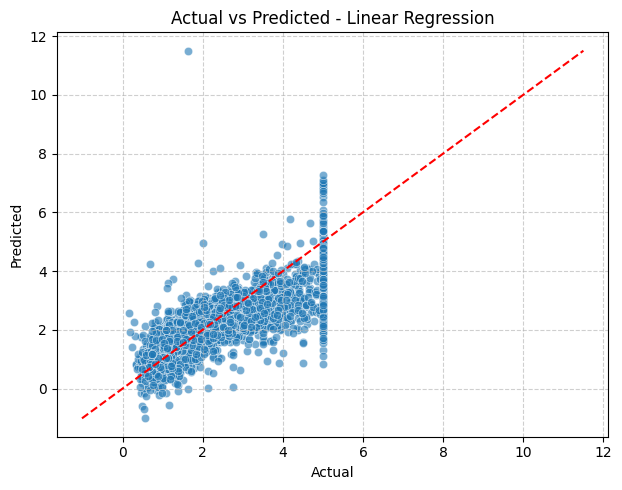

In [73]:
if ML_TYPE == 'regression':
    plot_actual_vs_predicted(best_models, X_test, y_test)

---
---
## **📈 CB4.2. Residual Plot**

**_Are the residuals well-behaved?_**

- **What it does**: Plots residuals (`y_true` - `y_pred`) vs predicted values.

- **Use**: Detects bias, non-linearity, and heteroscedasticity.

- **Ideal outcome**: Residuals scattered randomly around 0.

In [74]:
def plot_residuals(models, X_test, y_test):
    n = len(models)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(cols * 6, rows * 5))

    for i, (name, model) in enumerate(models.items(), 1):
        y_pred = model.predict(X_test)
        residuals = y_test - y_pred

        plt.subplot(rows, cols, i)
        sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
        plt.axhline(0, color='r', linestyle='--')  # horizontal zero line

        plt.xlabel("Predicted")
        plt.ylabel("Residuals (Actual - Predicted)")
        plt.title(f"Residual Plot - {name}")
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


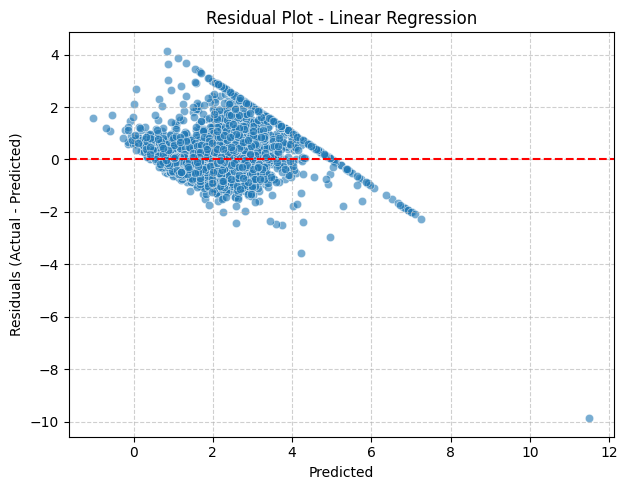

In [75]:
if ML_TYPE == 'regression':
    plot_residuals(best_models, X_test, y_test)

---
---
## **📈 CB4.3. Learning Curves**

**_Is the model improving with more data?_**

- **What it does**: Plots training and validation scores vs dataset size.

- **Use**: Diagnoses underfitting or overfitting.

- **Ideal outcome**: Validation and training scores converge and are high.

In [76]:
from sklearn.model_selection import learning_curve, KFold
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X_train, y_train, scoring='r2', cv_splits=5):
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes,
        cv=KFold(n_splits=cv_splits, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation score')
    
    plt.title(f'Learning Curve - {model.__class__.__name__}', fontsize=14)
    plt.xlabel('Training examples', fontsize=12)
    plt.ylabel(scoring.upper(), fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


📈 Plotting learning curve for: Linear Regression


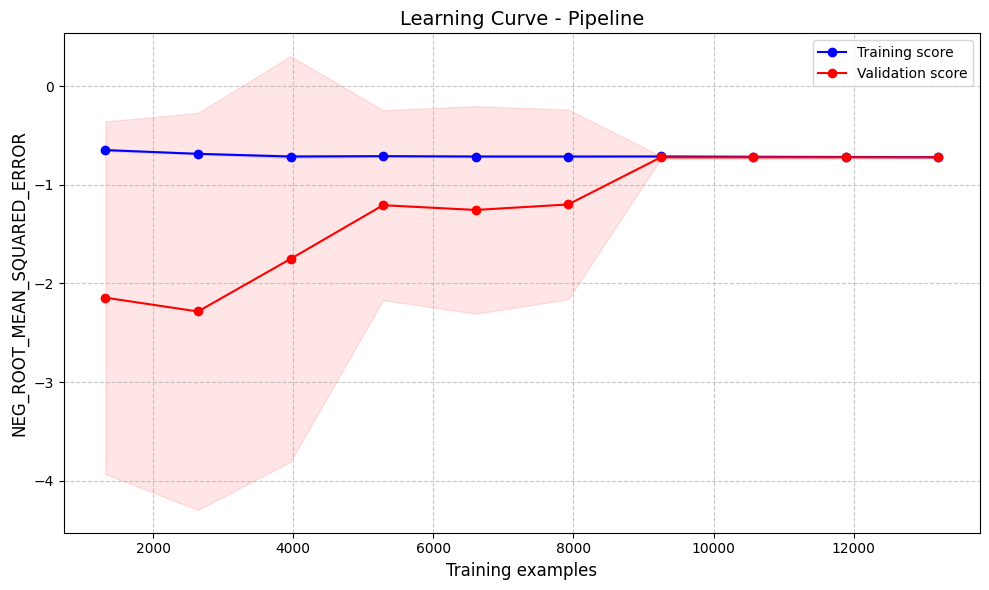

In [77]:
if ML_TYPE == 'regression':
    for name, model in best_models.items():
        print(f"📈 Plotting learning curve for: {name}")
        plot_learning_curve(model, X_train, y_train, scoring=CV_SCORING, cv_splits=CV)    

---
---
## **📈 CB4.4. Q-Q Plot**

**_Do residuals follow a normal distribution?_**

- **What it does**: Compares residual quantiles to normal distribution quantiles.

- **Use**: Assesses whether residuals are normally distributed (important for some models).

- **Ideal outcome**: Points lie close to the diagonal line.

In [78]:
import scipy.stats as stats

def plot_qq_plots(models, X_test, y_test):
    n = len(models)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(cols * 6, rows * 5))

    for i, (name, model) in enumerate(models.items(), 1):
        y_pred = model.predict(X_test)
        residuals = y_test - y_pred

        plt.subplot(rows, cols, i)
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title(f"QQ Plot of Residuals - {name}")
        plt.xlabel("Theoretical Quantiles")
        plt.ylabel("Sample Quantiles")
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

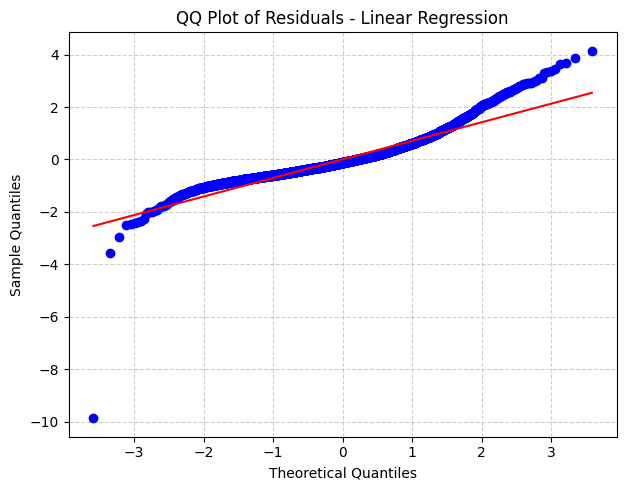

In [79]:
plot_qq_plots(best_models, X_test, y_test)

# **---------------------------------------------------------------------------------**
# **✅ D. MLOPS**

---
---
---